# Clinical NER Pipeline: GRU and GRU + GENIA

This notebook trains and compares two GRU-based clinical NER models on BC5CDR:

1. **GRU**
2. **GRU + GENIA**

The GENIA data is used as negative-sample augmentation by assigning all GENIA tokens the label `O`.

## Step 0: Environment Setup

Install the required libraries, define dataset paths, and verify that the BC5CDR and GENIA folders are available.

In [1]:
# Local notebook environment setup
!pip install -q "seqeval==1.2.2"
print("Dependencies installed. No training/evaluation is executed automatically.")

Dependencies installed. No training/evaluation is executed automatically.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import json
import copy
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from seqeval.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# GPU by default when available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Project paths (updated to local Processed_Data layout)
DATA_ROOT = os.path.abspath("drive/MyDrive/Processed_Data")
BC5CDR_DIR = os.path.join(DATA_ROOT, "ner", "bc5cdr")
GENIA_DIR = os.path.join(DATA_ROOT, "triggers", "genia")
OUTPUT_DIR = "./output"

GRU_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "results_gru")
GRU_GENIA_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "results_gru_genia")

os.makedirs(GRU_OUTPUT_DIR, exist_ok=True)
os.makedirs(GRU_GENIA_OUTPUT_DIR, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("BC5CDR_DIR exists:", os.path.exists(BC5CDR_DIR))
print("GENIA_DIR exists:", os.path.exists(GENIA_DIR))
print("Using device:", device)

DATA_ROOT: /content/drive/MyDrive/Processed_Data
BC5CDR_DIR exists: True
GENIA_DIR exists: True
Using device: cuda


## Step 1: Data Loading and Inspection

Load BC5CDR train/validation/test and GENIA training data, then inspect the label distribution and an example.

In [4]:
def load_jsonl(file_path):
    data = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return data

train_data = load_jsonl(os.path.join(BC5CDR_DIR, "train.jsonl"))
val_data = load_jsonl(os.path.join(BC5CDR_DIR, "validation.jsonl"))
test_data = load_jsonl(os.path.join(BC5CDR_DIR, "test.jsonl"))
genia_train_raw = load_jsonl(os.path.join(GENIA_DIR, "train.jsonl"))

print(f"Loaded BC5CDR train: {len(train_data)}")
print(f"Loaded BC5CDR validation: {len(val_data)}")
print(f"Loaded BC5CDR test: {len(test_data)}")
print(f"Loaded GENIA train: {len(genia_train_raw)}")


Loaded BC5CDR train: 5228
Loaded BC5CDR validation: 5330
Loaded BC5CDR test: 5865
Loaded GENIA train: 7388


In [5]:
all_labels = [label for doc in train_data for label in doc["labels"]]
label_counts = Counter(all_labels)

print("Label distribution in BC5CDR training set:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

seq_lengths = [len(doc["tokens"]) for doc in train_data]
print(f"\nSequence length statistics")
print(f"  Mean: {np.mean(seq_lengths):.2f}")
print(f"  Max : {np.max(seq_lengths)}")
print(f"  Min : {np.min(seq_lengths)}")

print("\nSample BC5CDR training example:")
sample = train_data[0]
for token, label in zip(sample["tokens"][:40], sample["labels"][:40]):
    print(f"{token:20} {label}")


Label distribution in BC5CDR training set:
  B-Chemical: 5203
  O: 96796
  B-Disease: 4182
  I-Disease: 2570
  I-Chemical: 571

Sequence length statistics
  Mean: 20.91
  Max : 133
  Min : 1

Sample BC5CDR training example:
Naloxone             B-Chemical
reverses             O
the                  O
antihypertensive     O
effect               O
of                   O
clonidine            B-Chemical
.                    O


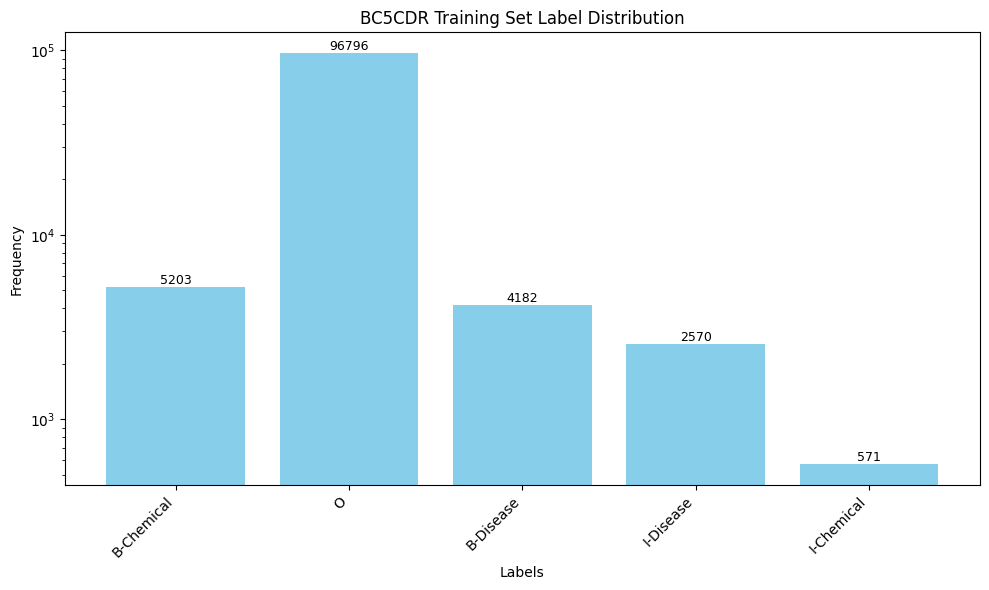

In [6]:
plt.figure(figsize=(10, 6))
ax = plt.bar(label_counts.keys(), label_counts.values(), color='skyblue')
plt.xlabel('Labels')
plt.ylabel('Frequency')
plt.title('BC5CDR Training Set Label Distribution')
plt.xticks(rotation=45, ha='right')
plt.yscale('log') # Apply logarithmic scale to make smaller values visible

# Add frequency numbers on top of each bar
for bar in ax:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Step 2: Label Setup, Vocabulary, and Tensor Conversion

Prepare the label vocabulary, token vocabulary, and tensor conversion utilities for GRU token classification.

In [7]:
label_names = ["O", "B-Chemical", "I-Chemical", "B-Disease", "I-Disease"]
label2id = {label: i for i, label in enumerate(label_names)}
id2label = {i: label for label, i in label2id.items()}

PAD_TOKEN = "[PAD]"
UNK_TOKEN = "[UNK]"
PAD_ID = 0
UNK_ID = 1

def build_vocab(data):
    vocab = {PAD_TOKEN: PAD_ID, UNK_TOKEN: UNK_ID}
    for doc in data:
        for tok in doc["tokens"]:
            t = tok.lower()
            if t not in vocab:
                vocab[t] = len(vocab)
    return vocab

vocab = build_vocab(train_data)

print("Label mapping:", label2id)
print("Vocab size:", len(vocab))

Label mapping: {'O': 0, 'B-Chemical': 1, 'I-Chemical': 2, 'B-Disease': 3, 'I-Disease': 4}
Vocab size: 8708


In [8]:
def encode_tokens(tokens, vocab_map):
    return [vocab_map.get(tok.lower(), UNK_ID) for tok in tokens]

def encode_labels(labels):
    return [label2id[lbl] for lbl in labels]

class NERSequenceDataset(Dataset):
    def __init__(self, records, vocab_map):
        self.samples = []
        for rec in records:
            input_ids = encode_tokens(rec["tokens"], vocab_map)
            label_ids = encode_labels(rec["labels"] )
            self.samples.append({
                "input_ids": input_ids,
                "labels": label_ids,
                "tokens": rec["tokens"],
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

def collate_fn(batch):
    max_len = max(len(x["input_ids"]) for x in batch)
    bsz = len(batch)

    input_ids = torch.full((bsz, max_len), PAD_ID, dtype=torch.long)
    labels = torch.full((bsz, max_len), -100, dtype=torch.long)
    attention_mask = torch.zeros((bsz, max_len), dtype=torch.long)
    tokens = []

    for i, sample in enumerate(batch):
        seq_len = len(sample["input_ids"] )
        input_ids[i, :seq_len] = torch.tensor(sample["input_ids"], dtype=torch.long)
        labels[i, :seq_len] = torch.tensor(sample["labels"], dtype=torch.long)
        attention_mask[i, :seq_len] = 1
        tokens.append(sample["tokens"] )

    return {
        "input_ids": input_ids,
        "labels": labels,
        "attention_mask": attention_mask,
        "tokens": tokens,
    }

## Step 3: Dataset Preparation

Convert BC5CDR into PyTorch datasets and dataloaders for GRU training/evaluation.

In [9]:
train_dataset = NERSequenceDataset(train_data, vocab)
val_dataset = NERSequenceDataset(val_data, vocab)
test_dataset = NERSequenceDataset(test_data, vocab)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))
print("Train batches:", len(train_loader))

Train size: 5228
Validation size: 5330
Test size: 5865
Train batches: 327


In [10]:
sample_batch = next(iter(train_loader))
print("input_ids shape:", sample_batch["input_ids"].shape)
print("labels shape:", sample_batch["labels"].shape)
print("attention_mask shape:", sample_batch["attention_mask"].shape)

input_ids shape: torch.Size([16, 94])
labels shape: torch.Size([16, 94])
attention_mask shape: torch.Size([16, 94])


## Step 4: Evaluation Metrics

We compute micro precision, micro recall, micro F1, macro F1, Chemical F1, and Disease F1 (same evaluation protocol).

In [11]:
def compute_metrics_from_ids(pred_ids_list, true_ids_list):
    true_predictions = []
    true_labels = []

    for pred_ids, lab_ids in zip(pred_ids_list, true_ids_list):
        cur_preds = [label_names[p] for p in pred_ids]
        cur_labels = [label_names[l] for l in lab_ids]
        true_predictions.append(cur_preds)
        true_labels.append(cur_labels)

    precision_micro = precision_score(true_labels, true_predictions)
    recall_micro = recall_score(true_labels, true_predictions)
    f1_micro = f1_score(true_labels, true_predictions)

    report = classification_report(true_labels, true_predictions, output_dict=True, zero_division=0)
    chemical_f1 = report.get("Chemical", {}).get("f1-score", 0.0)
    disease_f1 = report.get("Disease", {}).get("f1-score", 0.0)

    return {
        "eval_precision_micro": precision_micro,
        "eval_recall_micro": recall_micro,
        "eval_f1_micro": f1_micro,
        "eval_f1_macro": float(np.mean([chemical_f1, disease_f1])),
        "eval_Chemical_f1": chemical_f1,
        "eval_Disease_f1": disease_f1,
    }

## Step 5: Baseline Model Training

Train the baseline GRU model on BC5CDR only.

In [12]:
class GRUNERModel(nn.Module):
    def __init__(self, vocab_size, num_labels,
                 emb_dim=200, hidden_dim=256, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_ID)
        self.gru = nn.GRU(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)
        x, _ = self.gru(x)
        x = self.dropout(x)
        logits = self.classifier(x)
        return logits

def run_inference(model, loader, device):
    model.eval()
    all_pred_ids = []
    all_true_ids = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids=input_ids)
            preds = torch.argmax(logits, dim=-1)

            for i in range(input_ids.size(0)):
                valid_mask = labels[i] != -100
                sample_true = labels[i][valid_mask].detach().cpu().tolist()
                sample_pred = preds[i][valid_mask].detach().cpu().tolist()
                all_true_ids.append(sample_true)
                all_pred_ids.append(sample_pred)

    return all_pred_ids, all_true_ids

def evaluate_loader(model, loader, device):
    pred_ids, true_ids = run_inference(model, loader, device)
    metrics = compute_metrics_from_ids(pred_ids, true_ids)
    return metrics, pred_ids, true_ids

In [13]:
def train_gru_model(train_loader, val_loader, output_dir, num_epochs=5, lr=1e-3):
    model = GRUNERModel(vocab_size=len(vocab), num_labels=len(label_names)).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-100)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    best_f1 = -1.0
    best_state = None
    history = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            logits = model(input_ids=input_ids)
            loss = criterion(logits.view(-1, len(label_names)), labels.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / max(len(train_loader), 1)
        val_metrics, _, _ = evaluate_loader(model, val_loader, device)

        row = {"epoch": epoch + 1, "train_loss": train_loss, **val_metrics}
        history.append(row)

        print(f"Epoch {epoch+1}/{num_epochs} - loss: {train_loss:.4f} - val_f1_micro: {val_metrics['eval_f1_micro']:.4f}")

        if val_metrics["eval_f1_micro"] > best_f1:
            best_f1 = val_metrics["eval_f1_micro"]
            best_state = copy.deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)

    model_path = os.path.join(output_dir, "best_model.pt")
    torch.save(model.state_dict(), model_path)
    print("Saved best model to:", model_path)

    return model, pd.DataFrame(history)

print("Starting GRU baseline training...")
model_gru, history_gru = train_gru_model(train_loader, val_loader, GRU_OUTPUT_DIR, num_epochs=10, lr=1e-3)

print("\nEvaluating GRU on test set:")
gru_test_results, gru_test_pred_ids, gru_test_true_ids = evaluate_loader(model_gru, test_loader, device)
gru_test_results

Starting GRU baseline training...
Epoch 1/10 - loss: 0.3184 - val_f1_micro: 0.4554
Epoch 2/10 - loss: 0.1414 - val_f1_micro: 0.5961
Epoch 3/10 - loss: 0.0668 - val_f1_micro: 0.6542
Epoch 4/10 - loss: 0.0298 - val_f1_micro: 0.6676
Epoch 5/10 - loss: 0.0128 - val_f1_micro: 0.6748
Epoch 6/10 - loss: 0.0061 - val_f1_micro: 0.6750
Epoch 7/10 - loss: 0.0035 - val_f1_micro: 0.6824
Epoch 8/10 - loss: 0.0023 - val_f1_micro: 0.6893
Epoch 9/10 - loss: 0.0018 - val_f1_micro: 0.6864
Epoch 10/10 - loss: 0.0014 - val_f1_micro: 0.6819
Saved best model to: ./output/results_gru/best_model.pt

Evaluating GRU on test set:


{'eval_precision_micro': np.float64(0.7826672049522272),
 'eval_recall_micro': np.float64(0.5929248649199714),
 'eval_f1_micro': np.float64(0.6747099767981438),
 'eval_f1_macro': 0.6742701727337846,
 'eval_Chemical_f1': np.float64(0.6885762521102983),
 'eval_Disease_f1': np.float64(0.659964093357271)}

## Step 6: GENIA Augmentation

Convert GENIA into negative examples and train **GRU + GENIA** on the combined dataset.

In [14]:
genia_train = []
for doc in genia_train_raw:
    genia_train.append({
        "tokens": doc["tokens"],
        "labels": ["O"] * len(doc["tokens"]),
    })

combined_train_data = train_data + genia_train
combined_train_dataset = NERSequenceDataset(combined_train_data, vocab)
combined_train_loader = DataLoader(combined_train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

print("Original BC5CDR train size:", len(train_data))
print("GENIA added:", len(genia_train))
print("Combined train size:", len(combined_train_data))

Original BC5CDR train size: 5228
GENIA added: 7388
Combined train size: 12616


In [15]:
print("Starting GRU + GENIA training...")
model_gru_genia, history_gru_genia = train_gru_model(
    combined_train_loader,
    val_loader,
    GRU_GENIA_OUTPUT_DIR,
    num_epochs=10,
    lr=1e-3,
 )

print("\nEvaluating GRU + GENIA on test set:")
gru_genia_test_results, gru_genia_test_pred_ids, gru_genia_test_true_ids = evaluate_loader(
    model_gru_genia,
    test_loader,
    device,
 )
gru_genia_test_results

Starting GRU + GENIA training...
Epoch 1/10 - loss: 0.0905 - val_f1_micro: 0.2782
Epoch 2/10 - loss: 0.0323 - val_f1_micro: 0.3133
Epoch 3/10 - loss: 0.0133 - val_f1_micro: 0.3407
Epoch 4/10 - loss: 0.0051 - val_f1_micro: 0.3699
Epoch 5/10 - loss: 0.0024 - val_f1_micro: 0.3559
Epoch 6/10 - loss: 0.0019 - val_f1_micro: 0.3843
Epoch 7/10 - loss: 0.0021 - val_f1_micro: 0.3833
Epoch 8/10 - loss: 0.0019 - val_f1_micro: 0.3682
Epoch 9/10 - loss: 0.0018 - val_f1_micro: 0.3827
Epoch 10/10 - loss: 0.0012 - val_f1_micro: 0.3954
Saved best model to: ./output/results_gru_genia/best_model.pt

Evaluating GRU + GENIA on test set:


{'eval_precision_micro': np.float64(0.8242822552749913),
 'eval_recall_micro': np.float64(0.2429401569986747),
 'eval_f1_micro': np.float64(0.3752755905511811),
 'eval_f1_macro': 0.3740236408146856,
 'eval_Chemical_f1': np.float64(0.39153439153439157),
 'eval_Disease_f1': np.float64(0.3565128900949796)}

In [27]:
import json
import os

# Define the output directory (already created earlier)
# OUTPUT_DIR = "./output"

# 1. The best_model.pt files are already saved in GRU_OUTPUT_DIR and GRU_GENIA_OUTPUT_DIR
#    during the training process, so no explicit copy is needed here.

# 2. Save the vocabulary (shared) to the OUTPUT_DIR
with open(os.path.join(OUTPUT_DIR, 'vocab.json'), 'w') as f:
    json.dump(vocab, f)

# 3. Save the label names (shared) to the OUTPUT_DIR
label_list = ["O", "B-Chemical", "I-Chemical", "B-Disease", "I-Disease"]
with open(os.path.join(OUTPUT_DIR, 'label_list.json'), 'w') as f:
    json.dump(label_list, f)

# 4. Save Architecture Hyperparameters (shared) to the OUTPUT_DIR
hparams = {
    "emb_dim": 200,
    "hidden_dim": 256,
    "num_layers": 1,
    "dropout": 0.3
}
with open(os.path.join(OUTPUT_DIR, 'hparams.json'), 'w') as f:
    json.dump(hparams, f)

print(f"Successfully exported shared artifacts to {OUTPUT_DIR}")
print("Shared artifacts:", [f for f in os.listdir(OUTPUT_DIR) if os.path.isfile(os.path.join(OUTPUT_DIR, f)) and f.endswith('.json')])
print(f"Individual model weights are in {GRU_OUTPUT_DIR} and {GRU_GENIA_OUTPUT_DIR}")

Successfully exported shared artifacts to ./output
Shared artifacts: ['vocab.json', 'hparams.json', 'label_list.json']
Individual model weights are in ./output/results_gru and ./output/results_gru_genia


## Step 7: Results Comparison

Compare the baseline and augmented GRU models.

In [30]:
def load_model_for_inference(output_dir, vocab_map, label_names):
    # Load hyperparameters
    with open(os.path.join(output_dir, 'hparams.json'), 'r') as f:
        hparams = json.load(f)

    # Instantiate the model (GRUNERModel is hardcoded)
    model = GRUNERModel(
        vocab_size=len(vocab_map),
        num_labels=len(label_names),
        emb_dim=hparams['emb_dim'],
        hidden_dim=hparams['hidden_dim'],
        num_layers=hparams['num_layers'],
        dropout=hparams['dropout'],
    ).to(device)

    # Load the state dictionary
    model_path = os.path.join(output_dir, "results_gru", "best_model.pt")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    return model

# Load the GRU model
loaded_gru_model = load_model_for_inference(OUTPUT_DIR, vocab, label_names)
print("GRU model loaded successfully for inference.")

# Prepare a sample document for inference
sample_text = "Aspirin reduces pain and inflammation."
sample_tokens = sample_text.lower().split()
sample_labels = ["B-Chemical", "O", "O", "B-Disease", "O"]

# Encode the sample (only tokens here, labels will be handled by NERSequenceDataset)
input_ids = encode_tokens(sample_tokens, vocab)

sample_inference_data = [{
    "input_ids": input_ids,
    "labels": sample_labels, # <--- Corrected this line
    "tokens": sample_tokens,
}]

sample_inference_dataset = NERSequenceDataset(sample_inference_data, vocab)
sample_inference_loader = DataLoader(sample_inference_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

# Run inference
pred_ids, true_ids = run_inference(loaded_gru_model, sample_inference_loader, device)

print("\n--- Inference Results ---")
print(f"Sample Text: {sample_text}")
print(f"{'Token':<15} | {'True Label':<15} | {'Predicted Label':<15}")
print("-" * 50)
for token, true_id, pred_id in zip(sample_tokens, true_ids[0], pred_ids[0]):
    print(f"{token:<15} | {id2label[true_id]:<15} | {id2label[pred_id]:<15}")

GRU model loaded successfully for inference.

--- Inference Results ---
Sample Text: Aspirin reduces pain and inflammation.
Token           | True Label      | Predicted Label
--------------------------------------------------
aspirin         | B-Chemical      | B-Chemical     
reduces         | O               | B-Disease      
pain            | O               | B-Disease      
and             | B-Disease       | O              
inflammation.   | O               | O              


In [17]:
results_data = [
    {
        "Model": "GRU",
        "Precision": gru_test_results["eval_precision_micro"],
        "Recall": gru_test_results["eval_recall_micro"],
        "F1 (micro)": gru_test_results["eval_f1_micro"],
        "F1 (macro)": gru_test_results["eval_f1_macro"],
        "Chemical F1": gru_test_results["eval_Chemical_f1"],
        "Disease F1": gru_test_results["eval_Disease_f1"],
    },
    {
        "Model": "GRU + GENIA",
        "Precision": gru_genia_test_results["eval_precision_micro"],
        "Recall": gru_genia_test_results["eval_recall_micro"],
        "F1 (micro)": gru_genia_test_results["eval_f1_micro"],
        "F1 (macro)": gru_genia_test_results["eval_f1_macro"],
        "Chemical F1": gru_genia_test_results["eval_Chemical_f1"],
        "Disease F1": gru_genia_test_results["eval_Disease_f1"],
    },
]

results_df = pd.DataFrame(results_data).round(4)
display(results_df)

results_df.to_csv(os.path.join(OUTPUT_DIR, "gru_vs_gru_genia_results.csv"), index=False)
print("Saved:", os.path.join(OUTPUT_DIR, "gru_vs_gru_genia_results.csv"))

,Model,Precision,Recall,F1 (micro),F1 (macro),Chemical F1,Disease F1
0,GRU,0.7827,0.5929,0.6747,0.6743,0.6886,0.6600
1,GRU + GENIA,0.8243,0.2429,0.3753,0.3740,0.3915,0.3565


Saved: ./output/gru_vs_gru_genia_results.csv


## Step 8: Visualization and Model Comparison

Add bar charts and confusion matrices for GRU vs GRU + GENIA.

In [18]:
def flatten_word_level_predictions(pred_ids_list, true_ids_list, label_names):
    y_true, y_pred = [], []
    for pred_ids, true_ids in zip(pred_ids_list, true_ids_list):
        pred_tags = [label_names[idx] for idx in pred_ids]
        true_tags = [label_names[idx] for idx in true_ids]

        if len(pred_tags) == len(true_tags):
            y_true.extend(true_tags)
            y_pred.extend(pred_tags)
    return y_true, y_pred

def collapse_entity(tag):
    if tag == "O":
        return "O"
    return tag.split("-")[-1]

def plot_confusion_matrix_simple(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

In [19]:
gru_true, gru_pred = flatten_word_level_predictions(gru_test_pred_ids, gru_test_true_ids, label_names)
grug_true, grug_pred = flatten_word_level_predictions(gru_genia_test_pred_ids, gru_genia_test_true_ids, label_names)

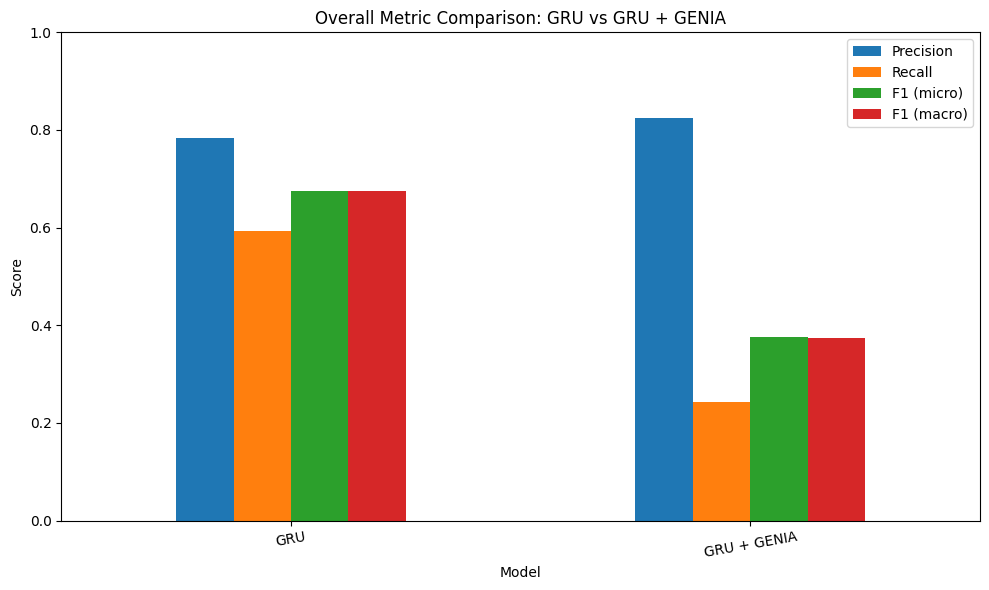

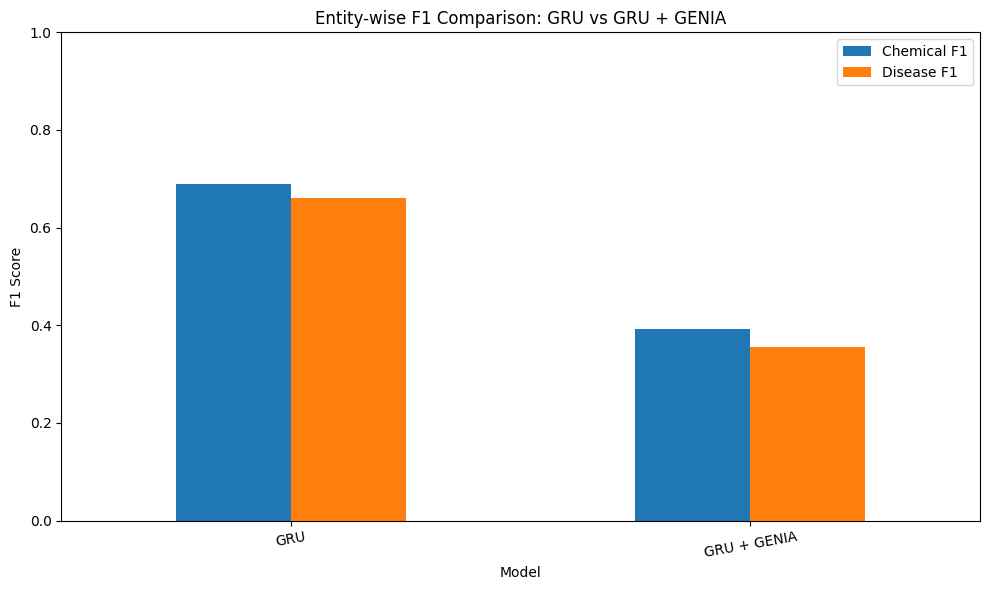

In [20]:
plot_df = results_df.set_index("Model")[["Precision", "Recall", "F1 (micro)", "F1 (macro)"]]
ax = plot_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Overall Metric Comparison: GRU vs GRU + GENIA")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

entity_df = results_df.set_index("Model")[["Chemical F1", "Disease F1"]]
ax = entity_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Entity-wise F1 Comparison: GRU vs GRU + GENIA")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

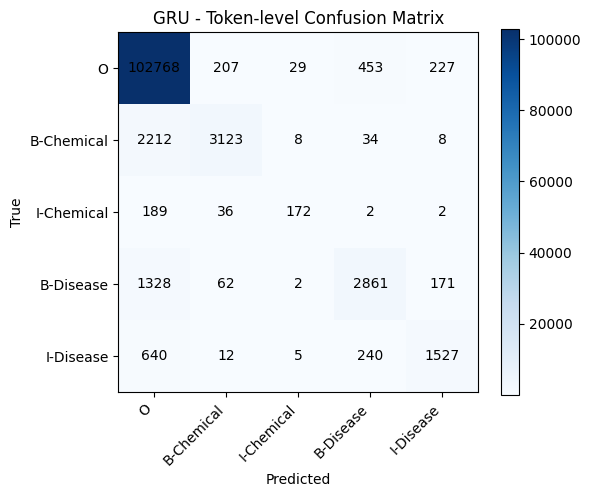

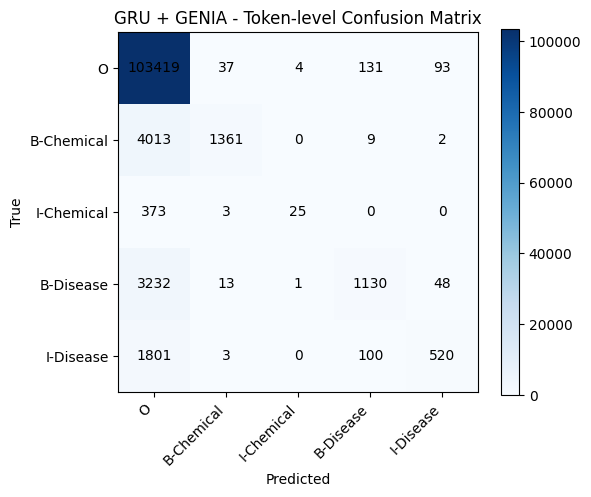

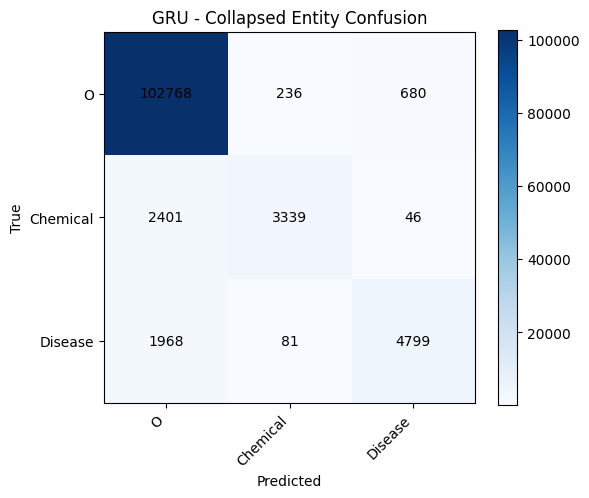

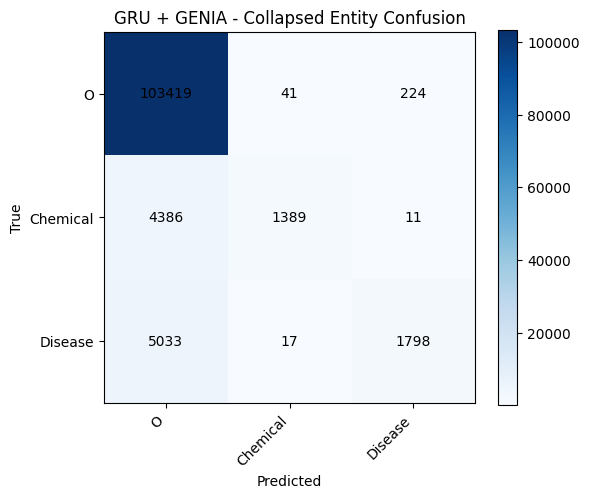

In [21]:
labels_full = ["O", "B-Chemical", "I-Chemical", "B-Disease", "I-Disease"]

plot_confusion_matrix_simple(gru_true, gru_pred, labels_full, "GRU - Token-level Confusion Matrix")
plot_confusion_matrix_simple(grug_true, grug_pred, labels_full, "GRU + GENIA - Token-level Confusion Matrix")

gru_true_c = [collapse_entity(x) for x in gru_true]
gru_pred_c = [collapse_entity(x) for x in gru_pred]
grug_true_c = [collapse_entity(x) for x in grug_true]
grug_pred_c = [collapse_entity(x) for x in grug_pred]

labels_collapsed = ["O", "Chemical", "Disease"]

plot_confusion_matrix_simple(gru_true_c, gru_pred_c, labels_collapsed, "GRU - Collapsed Entity Confusion")
plot_confusion_matrix_simple(grug_true_c, grug_pred_c, labels_collapsed, "GRU + GENIA - Collapsed Entity Confusion")

## Step 9: Effect of GENIA Augmentation

Measure the gain from adding GENIA to GRU.

,Base Model,Micro F1 Gain,Macro F1 Gain,Chemical F1 Gain,Disease F1 Gain
0,GRU,-0.2994,-0.3002,-0.297,-0.3035


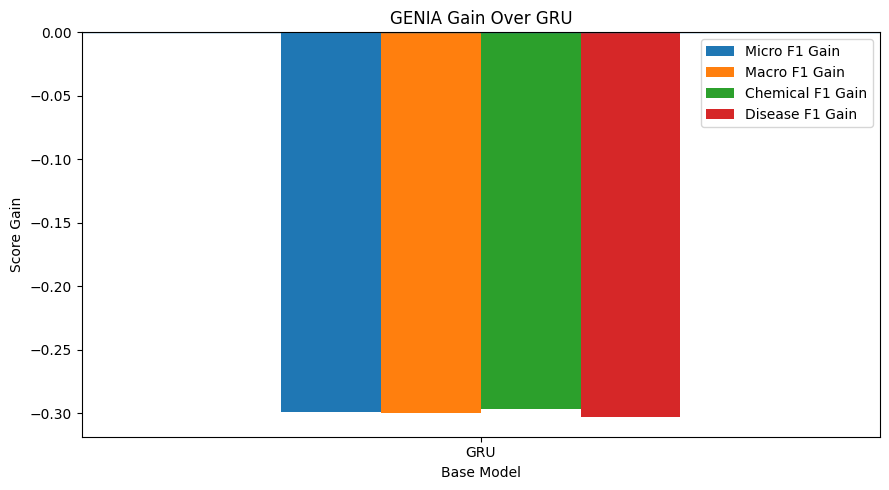

In [22]:
improvement_df = pd.DataFrame({
    "Base Model": ["GRU"],
    "Micro F1 Gain": [
        gru_genia_test_results["eval_f1_micro"] - gru_test_results["eval_f1_micro"]
    ],
    "Macro F1 Gain": [
        gru_genia_test_results["eval_f1_macro"] - gru_test_results["eval_f1_macro"]
    ],
    "Chemical F1 Gain": [
        gru_genia_test_results["eval_Chemical_f1"] - gru_test_results["eval_Chemical_f1"]
    ],
    "Disease F1 Gain": [
        gru_genia_test_results["eval_Disease_f1"] - gru_test_results["eval_Disease_f1"]
    ]
}).round(4)

display(improvement_df)

ax = improvement_df.set_index("Base Model").plot(kind="bar", figsize=(9, 5))
ax.set_title("GENIA Gain Over GRU")
ax.set_ylabel("Score Gain")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 10: Error Analysis

Inspect cases where **GRU + GENIA** corrects mistakes made by **GRU**.

In [23]:
examples_shown = 0
print("=" * 100)
print("Examples where GRU failed but GRU + GENIA succeeded")
print("=" * 100)

for i in range(len(test_data)):
    tokens = test_data[i]["tokens"]
    actual_tags = test_data[i]["labels"]

    if i >= len(gru_test_pred_ids) or i >= len(gru_genia_test_pred_ids):
        continue

    gru_word_preds = [label_names[idx] for idx in gru_test_pred_ids[i]]
    gru_genia_word_preds = [label_names[idx] for idx in gru_genia_test_pred_ids[i]]

    if len(gru_word_preds) != len(tokens) or len(gru_genia_word_preds) != len(tokens):
        continue

    gru_correct = (gru_word_preds == actual_tags)
    gru_genia_correct = (gru_genia_word_preds == actual_tags)

    if (not gru_correct) and gru_genia_correct:
        print(f"\nExample {examples_shown + 1}")
        print(f"{'Token':<20} | {'True':<15} | {'GRU':<15} | {'GRU+GENIA':<15}")
        print("-" * 80)
        for tk, tr, gp, ggp in zip(tokens, actual_tags, gru_word_preds, gru_genia_word_preds):
            mark = "*" if gp != tr else ""
            print(f"{tk:<20} | {tr:<15} | {gp + mark:<15} | {ggp:<15}")

        examples_shown += 1
        if examples_shown >= 10:
            break

if examples_shown == 0:
    print("No examples found.")

Examples where GRU failed but GRU + GENIA succeeded

Example 1
Token                | True            | GRU             | GRU+GENIA      
--------------------------------------------------------------------------------
I                    | O               | O               | O              
.)                   | O               | O               | O              
for                  | O               | O               | O              
methamphetamine      | B-Chemical      | B-Chemical      | B-Chemical     
-                    | O               | O               | O              
induced              | O               | O               | O              
psychosis            | B-Disease       | B-Disease       | B-Disease      
and                  | O               | O               | O              
other                | O               | O               | O              
Axis                 | O               | B-Disease*      | O              
I                    | O       

## Step 11: Conclusion

### Why GRU + GENIA Can Underperform While BERT Stays More Stable
- **Label skew effect**: GENIA is converted to all `O`, so adding too much GENIA increases class imbalance toward non-entity tokens.
- **BiGRU sensitivity**: a BiGRU trained from scratch can overfit this skew and miss true entities (recall drop).
- **BERT robustness**: BERT usually degrades less because it has stronger pretrained representations and global context modeling from self-attention.
- **Not only attention**: the gap is typically due to a combination of self-attention + pretraining + better robustness to distribution shift.